In [2]:
import pandas as pd
data = pd.read_csv('insurance.csv')

In [3]:
data.isna().sum()

age          0
sex          0
bmi         11
children     0
smoker       0
region       0
charges      0
dtype: int64

In [4]:
data.bmi.fillna(data.bmi.mean(),inplace=True)

In [5]:
data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
data.duplicated().sum()

1

In [7]:
data.drop_duplicates(inplace=True)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [9]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,30.667841,0,yes,southwest,16884.92400
1,18,male,33.770000,1,no,southeast,1725.55230
2,28,male,33.000000,3,no,southeast,4449.46200
3,33,male,22.705000,0,no,northwest,21984.47061
4,32,male,28.880000,0,no,northwest,3866.85520


In [10]:
pd.get_dummies(data,dtype=int)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_middle,region_northeast,region_northwest,region_southeast,region_southwest
0,19,30.667841,0,16884.92400,1,0,0,1,0,0,0,0,1
1,18,33.770000,1,1725.55230,0,1,1,0,0,0,0,1,0
2,28,33.000000,3,4449.46200,0,1,1,0,0,0,0,1,0
3,33,22.705000,0,21984.47061,0,1,1,0,0,0,1,0,0
4,32,28.880000,0,3866.85520,0,1,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970000,3,10600.54830,0,1,1,0,0,0,1,0,0
1334,18,31.920000,0,2205.98080,1,0,1,0,0,1,0,0,0
1335,18,36.850000,0,1629.83350,1,0,1,0,0,0,0,1,0
1336,21,25.800000,0,2007.94500,1,0,1,0,0,0,0,0,1


In [11]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
encoded_categories = ohe.fit_transform(data.select_dtypes('O'))

C:\Users\Administrator\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [12]:
encoded_categories = encoded_categories.toarray()

In [13]:
ohe.feature_names_in_

array(['sex', 'smoker', 'region'], dtype=object)

In [14]:
ohe.get_feature_names_out()

array(['sex_female', 'sex_male', 'smoker_no', 'smoker_yes',
       'region_middle', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest'], dtype=object)

In [15]:
encoded_categories = pd.DataFrame(data=encoded_categories, columns=ohe.get_feature_names_out())

In [16]:
numbered_data = data.select_dtypes('number')
numbered_data

,age,bmi,children,charges
0,19,30.667841,0,16884.92400
1,18,33.770000,1,1725.55230
2,28,33.000000,3,4449.46200
3,33,22.705000,0,21984.47061
4,32,28.880000,0,3866.85520
...,...,...,...,...
1333,50,30.970000,3,10600.54830
1334,18,31.920000,0,2205.98080
1335,18,36.850000,0,1629.83350
1336,21,25.800000,0,2007.94500


In [17]:
df = pd.concat([numbered_data,encoded_categories],axis=1)

In [18]:
df.dropna(inplace=True, axis=0)

In [19]:
df

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_middle,region_northeast,region_northwest,region_southeast,region_southwest
0,19.0,30.667841,0.0,16884.92400,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,18.0,33.770000,1.0,1725.55230,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,28.0,33.000000,3.0,4449.46200,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,33.0,22.705000,0.0,21984.47061,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,32.0,28.880000,0.0,3866.85520,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332,52.0,44.700000,3.0,11411.68500,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1333,50.0,30.970000,3.0,10600.54830,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1334,18.0,31.920000,0.0,2205.98080,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1335,18.0,36.850000,0.0,1629.83350,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [20]:
X = df.drop('charges',axis=1)
y = df.charges

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [23]:
y_pred_train = lr.predict(X_train)

In [24]:
from sklearn.metrics import mean_squared_error, r2_score

In [25]:
mean_squared_error(y_train,y_pred_train)

118761828.91019906

In [26]:
r2_score(y_train,y_pred_train)

0.1525780934317006

In [27]:
y_pred_test = lr.predict(X_test)

In [28]:
r2_score(y_test,y_pred_test)

0.1870053002422889

In [29]:
from sklearn.preprocessing import MinMaxScaler

In [47]:
X

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_middle,region_northeast,region_northwest,region_southeast,region_southwest
0,19.0,30.667841,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,18.0,33.770000,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,28.0,33.000000,3.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,33.0,22.705000,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,32.0,28.880000,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1332,52.0,44.700000,3.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1333,50.0,30.970000,3.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1334,18.0,31.920000,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1335,18.0,36.850000,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [30]:
scaler = MinMaxScaler()
scaled_X = scaler.fit_transform(X)

In [33]:
scaled_X = pd.DataFrame(data=scaled_X, columns=scaler.get_feature_names_out())
scaled_X

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_middle,region_northeast,region_northwest,region_southeast,region_southwest
0,0.021956,0.395691,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.020958,0.479150,0.2,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.030938,0.458434,0.6,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.035928,0.181464,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.034930,0.347592,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1331,0.054890,0.773204,0.6,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1332,0.052894,0.403820,0.6,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1333,0.020958,0.429379,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1334,0.020958,0.562012,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size=0.3, random_state=42)

In [44]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [45]:
y_pred_train = lr.predict(X_train)

In [46]:
r2_score(y_train,y_pred_train)

0.1525780934317006

# PolynomialRegression

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

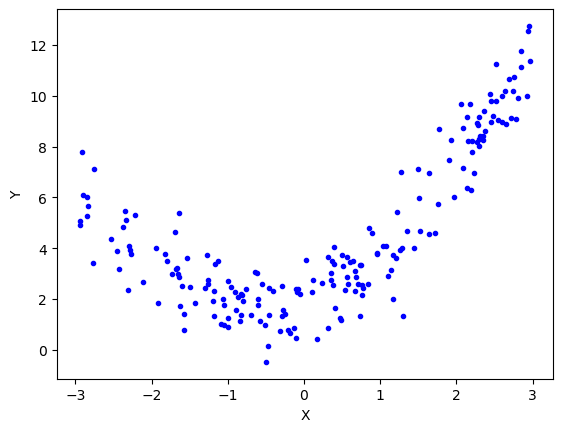

In [61]:
import numpy as np
import matplotlib.pyplot as plt

X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9*X + 2 + np.random.randn(200, 1)
#equation used -> y = 0.8x^2 + 0.9x + 2
#visualize the data
plt.plot(X, y, 'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [58]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [62]:
x_train

array([[-1.20171440e+00],
       [ 1.40404231e+00],
       [ 3.48065781e-01],
       [-1.30108579e+00],
       [-1.28864637e+00],
       [-2.17595265e+00],
       [ 1.91026160e+00],
       [ 1.21569004e+00],
       [-1.19626675e+00],
       [-1.54656687e+00],
       [ 1.67621923e-03],
       [ 1.01280045e+00],
       [-7.55273896e-01],
       [-1.43396341e+00],
       [-1.14485898e+00],
       [ 4.97441772e-01],
       [-1.52131664e+00],
       [-2.16209990e+00],
       [-2.35237566e+00],
       [ 1.31250205e+00],
       [ 2.66447832e+00],
       [-1.52352387e+00],
       [ 2.06323720e+00],
       [ 2.68656519e+00],
       [ 2.76470772e+00],
       [-2.30893284e+00],
       [-1.96630458e+00],
       [ 1.53648561e+00],
       [-7.85368914e-01],
       [ 2.54168191e+00],
       [-7.78218752e-01],
       [ 1.31197279e+00],
       [-1.65859119e+00],
       [ 1.38446749e+00],
       [-4.28764560e-01],
       [-2.43707049e+00],
       [ 2.29767437e+00],
       [-1.63297429e+00],
       [ 2.7

In [51]:
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print(r2_score(y_test, y_pred))

0.40883640390138465


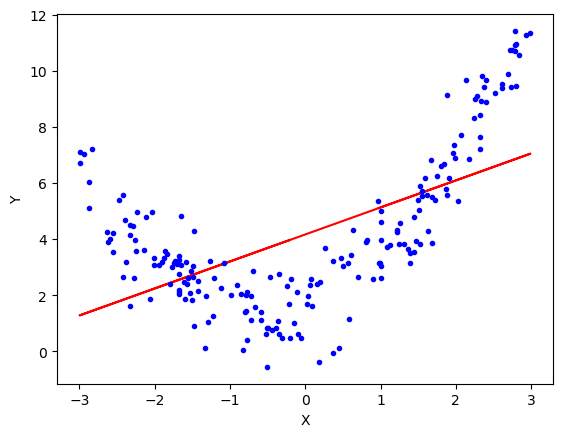

In [52]:
plt.plot(x_train, lr.predict(x_train), color="r")
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [82]:
#applying polynomial regression degree 2
poly = PolynomialFeatures(degree=4, include_bias=True)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)


In [83]:
poly.get_feature_names_out()

array(['1', 'x0', 'x0^2', 'x0^3', 'x0^4'], dtype=object)

In [80]:
lr = LinearRegression()
lr.fit(x_train_trans, y_train)
y_pred = lr.predict(x_test_trans)
print(r2_score(y_test, y_pred))

0.8967442336963843


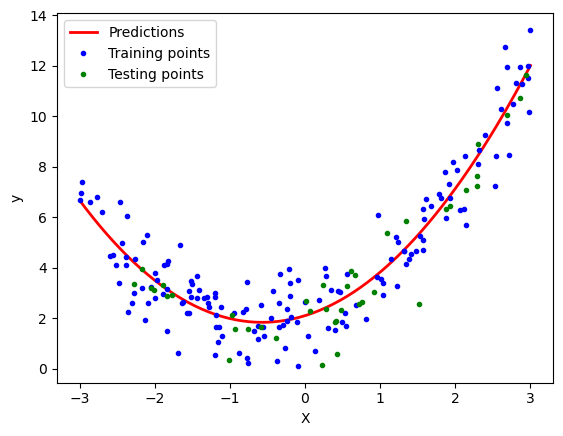

In [81]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()